In [1]:
%cd drive/MyDrive/NLP

/content/drive/MyDrive/NLP


In [2]:
!pip install -U -q neo4j langchain langchain-community langchain-core langchain-chroma langchain-text-splitters langchain-huggingface unstructured langchain-google-genai matplotlib pandas rank_bm25

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 21.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 2.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.4/325.4 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.9/475.9 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 122.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter, MarkdownHeaderTextSplitter
from langchain_core.documents import Document
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import HumanMessage, AIMessage
from langchain.tools import tool
from langchain_classic.agents import AgentExecutor, create_react_agent
from langchain_classic.retrievers import EnsembleRetriever, ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.retrievers import BM25Retriever
from langchain_community.cross_encoders import HuggingFaceCrossEncoder


from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

from IPython.display import Image, display
from neo4j import GraphDatabase
import pandas as pd
import matplotlib.pyplot as plt
import torch

import csv
import json
import re

# LLM General

Voy a usar el modelo Gemini 2.5 en la nuve como llm para generar querys, outputs limpios y ser el cerebro del Agente.

In [ ]:
GOOGLE_API_KEY = ""

# LLM general (Gemini en la nube)
llm_gemini = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=GOOGLE_API_KEY,
)


# Fuentes de información


## Vectorial


In [ ]:
HF_TOKEN = ''

In [6]:
class GestorVectorial:
    def __init__(self, hf_token, persist_dir="./chroma_db"):
        self.persist_dir = persist_dir

        # Configuración del modelo de embeddings y de rerank
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        model_kwargs = {'device': device, 'token': hf_token}

        self.embedding_model = HuggingFaceEmbeddings(
            model_name="google/embeddinggemma-300m",
            model_kwargs=model_kwargs
        )

        self.rerank_model = HuggingFaceCrossEncoder(
            model_name="cross-encoder/mmarco-mMiniLMv2-L12-H384-v1",
            model_kwargs=model_kwargs
        )


        self.vectorstore = None
        self.retriever = None

    def _procesar_manuales(self, ruta_dir):
        """Lógica compleja de manuales: Markdown Split + Regex + Inyección de Contexto"""

        loader = DirectoryLoader(ruta_dir, glob="*.md", loader_cls=TextLoader)
        manuales = loader.load()

        # Splitters primero por sección subsección (Encabezados de MD) y luego
        # por longitud (En caso de que la subsección sea muy extensa)

        headers = [("##", "Seccion"), ("###", "Subseccion")]
        md_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers, strip_headers=False)
        rec_splitter = RecursiveCharacterTextSplitter(
            chunk_size=500, chunk_overlap=50, separators=["\n\n", "\n", ". ", " ", ""]
        )

        # Patrones regex para extraer nombre y módelo del producto
        patron_modelo = re.compile(r"\*\*Modelo:\*\*\s*([^|]+?)\s*\|\s*\*\*Marca:\*\*\s*(.+)")
        patron_producto = re.compile(r"#\s*Manual Técnico\s*-\s*(.+)")

        docs_procesados = []

        for m in manuales:
            contenido = m.page_content
            marca, modelo, producto = 'Generica', 'Generico', 'Desconocido'

            # Split por headers de markdown
            splits_md = md_splitter.split_text(contenido)

            if not splits_md: continue

            # Extracción de Metadata del encabezado
            encabezado = splits_md.pop(0)

            match_mod = patron_modelo.search(encabezado.page_content)
            if match_mod:
                modelo = match_mod.group(1).strip()
                marca = match_mod.group(2).strip()

            match_prod = patron_producto.search(encabezado.page_content)
            if match_prod:
                producto = match_prod.group(1).strip()

            # Procesamiento de secciones restantes
            for s_md in splits_md:
                # Split Recursivo por tamaño
                for s_r in rec_splitter.split_documents([s_md]):
                    # Inyección de Metadata y Contexto
                    s_r.metadata = {
                        'producto': producto,
                        'marca': marca,
                        'modelo': modelo,
                        'tipo': 'manual',
                        'origen': m.metadata.get('source', ''),
                    }
                    contexto = f"Manual Producto {producto} Marca: {marca} Modelo: {modelo}\n"
                    s_r.page_content = contexto + s_r.page_content

                    docs_procesados.append(s_r)

        return docs_procesados

    def _procesar_faqs(self, ruta_json):
        """Carga y formateo de FAQs desde JSON"""
        faqs_procesadas = []
        try:
            with open(ruta_json, 'r', encoding='utf-8') as f:
                data = json.load(f)

            for item in data:
                pregunta = item.get("pregunta", "")
                respuesta = item.get("respuesta", "")
                producto = item.get("nombre_producto", "General")
                modelo = item.get("id_producto", "Generico")

                texto = f"FAQ Producto: {producto} Modelo: {modelo}\nPregunta: {pregunta}\nRespuesta: {respuesta}"
                meta = {'tipo': 'faq', 'producto': producto, 'modelo': modelo, 'origen': 'faqs.json'}

                faqs_procesadas.append(Document(page_content=texto, metadata=meta))
        except Exception as e:
            print(f"Error en FAQs: {e}")

        return faqs_procesadas

    def _procesar_resenas(self, ruta_dir):
        """Carga de reseñas y extracción de producto por Regex"""
        loader = DirectoryLoader(ruta_dir, glob="*.txt", loader_cls=TextLoader)
        reseñas = loader.load()

        patron_producto = r"^Producto:\s*(?P<nombre>.+?)\s*\((?P<modelo>[^)]+)\)$"
        resenas_procesadas = []

        for r in reseñas:
            texto = r.page_content
            try:
                # Separamos header del cuerpo de la reseña (formato consistente)
                if '\n\n' in texto:
                    datos, cuerpo = texto.split('\n\n', 1)
                else:
                    datos, cuerpo = texto, "" # Fallback si la reseña no tiene texto

                producto, modelo = 'Desconocido', 'Generico'

                match = re.search(patron_producto, datos, re.MULTILINE)
                if match:
                    producto = match.group('nombre').strip()
                    modelo = match.group('modelo').strip()

                r.metadata = {'producto': producto, 'modelo': modelo, 'tipo': 'reseña', 'origen': r.metadata.get('source','')}
                r.page_content = f"Reseña de Producto: {producto} Modelo: {modelo}\nOPINIÓN:\n{cuerpo}"

                resenas_procesadas.append(r)
            except Exception as e:
                print(f"Error procesando reseña {r.metadata.get('source')}: {e}")

        return resenas_procesadas

    def _configurar_retriever(self):
        """Busqueda híbrida Vectorial + BM25 -> ReRanker"""

        # Vectorial: Trae 5 candidatos por semántica
        vec_retriever = self.vectorstore.as_retriever(search_kwargs={"k": 5})

        # BM25: Trae 5 candidatos por palabras clave
        docs = self.vectorstore.get()['documents']
        metadatas = self.vectorstore.get()['metadatas']
        # Reconstruye docs desde chroma para BM25
        docs_obj = [Document(page_content=c, metadata=m) for c, m in zip(docs, metadatas)]
        bm25_retriever = BM25Retriever.from_documents(docs_obj)
        bm25_retriever.k = 5

        # Combina los resultados (total 10 candidatos)
        ensemble = EnsembleRetriever(
            retrievers=[bm25_retriever, vec_retriever],
            weights=[0.4, 0.6]
        )

        # ReRanker, elige mejores 3 candidatos
        reranker = CrossEncoderReranker(model=self.rerank_model, top_n=3)

        # Pipeline Final
        self.retriever = ContextualCompressionRetriever(
            base_compressor=reranker,
            base_retriever=ensemble
        )

    def construir_db(self, ruta_manuales, ruta_faqs, ruta_resenas):
        """Carga todas las fuentes y crea la base vectorial"""
        d_manuales = self._procesar_manuales(ruta_manuales)
        d_faqs = self._procesar_faqs(ruta_faqs)
        d_resenas = self._procesar_resenas(ruta_resenas)

        documentos = d_manuales + d_faqs + d_resenas

        self.vectorstore = Chroma.from_documents(
            documents=documentos,
            embedding=self.embedding_model,
            collection_name="productos_db",
            persist_directory=self.persist_dir
        )
        self._configurar_retriever()


    def cargar_db_existente(self):
        """Carga la base desde disco si ya existe (para no reprocesar)"""
        self.vectorstore = Chroma(
            persist_directory=self.persist_dir,
            embedding_function=self.embedding_model,
            collection_name="productos_db"
        )
        self._configurar_retriever()

    def consultar_vectorial(self, query, k=3):
        """Método de busqueda por semántica, con K configurable"""
        if not self.vectorstore:
            return "Error: La DB no está cargada."

        results = self.vectorstore.similarity_search(query, k=k)

        texto = ""
        for doc in results:
            meta = doc.metadata
            fuente = f"{meta.get('tipo', 'Doc')} - {meta.get('producto', '')}"
            texto += f"Fuente: {fuente}\n{doc.page_content}\n\n"

        return texto

    def consultar(self, query):
        """Método de búsqueda híbrida (semántica + bm25) con rerank, devuelve 3 mejores resultados"""

        if not self.vectorstore:
            return "Error: La DB no está cargada."

        results = self.retriever.invoke(query)

        texto = ""
        for doc in results:
            meta = doc.metadata
            fuente = f"{meta.get('tipo', 'Doc')} - {meta.get('producto', '')}"
            texto += f"Fuente: {fuente}\n{doc.page_content}\n\n"
        return texto

In [ ]:
gestor_vectorial = GestorVectorial(HF_TOKEN, "./chroma_db")

# gestor_vectorial.construir_db(
#     ruta_faqs='./fuentes_de_informacion/faqs.json',
#     ruta_manuales='./fuentes_de_informacion/manuales_productos',
#     ruta_resenas='./fuentes_de_informacion/resenas_usuarios',
# )

gestor_vectorial.cargar_db_existente()

## Tabular

In [8]:
class GestorTabular:
    def __init__(self):
        self.dfs = {}
        self.schemas = []

    def cargar_fuente(self, nombre_tabla, ruta_archivo):
        try:
            # Carga defensiva (prueba coma y punto y coma)
            try:
                df = pd.read_csv(ruta_archivo)
            except:
                df = pd.read_csv(ruta_archivo, sep=';')

            self.dfs[nombre_tabla] = df

            # Generar Schema (Resumen para el LLM)
            info = [f"TABLA: '{nombre_tabla}' ({len(df)} filas)"]
            info.append("COLUMNAS:")
            for col in df.columns:
                dtype = df[col].dtype
                if dtype == 'object':
                    ejemplos = list(df[col].dropna().unique()[:5])
                    info.append(f"  - {col} (Texto): Ejemplos {ejemplos}...")
                else:
                    info.append(f"  - {col} (Numérico): Rango [{df[col].min()} - {df[col].max()}]")

            self.schemas.append("\n".join(info))
            print(f"Tabla '{nombre_tabla}' cargada.")
        except Exception as e:
            print(f"Error cargando {nombre_tabla}: {e}")

    def obtener_schema(self):
        return "\n\n".join(self.schemas)

    def ejecutar(self, codigo):
        # Entorno seguro de ejecución
        local_vars = {"dfs": self.dfs, "pd": pd, "resultado": None}
        try:
            exec(codigo, {}, local_vars)
            return local_vars.get("resultado", "Error: El código no generó la variable 'resultado'")
        except Exception as e:
            return f"Error Ejecución: {e}"

    def consultar(self, pregunta, llm):
      template = """
      Eres un experto en Pandas. Tienes un diccionario `dfs`. Genera código Python basado en:
      SCHEMA: {schema}
      REGLAS: Guarda resultado en variable `resultado`. Solo código. Limita a 5 filas si no se especifica.
      PREGUNTA: {pregunta}
      """

      chain = PromptTemplate.from_template(template) | llm | StrOutputParser()
      codigo = chain.invoke({"schema": self.obtener_schema(), "pregunta": pregunta})
      codigo_limpio = codigo.replace("```python", "").replace("```", "").strip()

      return self.ejecutar(codigo_limpio)

    def graficar(self, pregunta, llm):
      template = '''
      Eres un experto en Pandas y Matplotib. Tienes un diccionario `dfs`. Genera código Python que genere un gráfico basado en:

      CONTEXTO DE EJECUCIÓN:
      El código que generes se ejecutará mediante `exec()` en un entorno donde **YA EXISTE** una variable llamada `dfs`.
      `dfs` es un diccionario de DataFrames de Pandas.

      ESQUEMA DE DATOS DISPONIBLE EN `dfs`:
      {schema}

      REGLAS:
      - Usa UNICAMENTE datos del diccionario de dfs siguiendo el esquema
      - Siempre termina con plt.show()
      - Devuelve UNICAMENTE código python
      - Asigna la variable resultado a un string indicando si el gráfico se genero correctamente o falló

      PREGUNTA: {pregunta}
      '''
      chain = PromptTemplate.from_template(template) | llm | StrOutputParser()
      codigo = chain.invoke({"schema": self.obtener_schema(), "pregunta": pregunta})
      codigo_limpio = codigo.replace("```python", "").replace("```", "").strip()

      return self.ejecutar(codigo_limpio) + f"generado mediante \n{codigo_limpio}"


In [9]:
gestor_tabular = GestorTabular()

gestor_tabular.cargar_fuente("productos", "fuentes_de_informacion/productos.csv")
gestor_tabular.cargar_fuente("ventas", "fuentes_de_informacion/ventas_historicas.csv")
gestor_tabular.cargar_fuente("tickets", "fuentes_de_informacion/tickets_soporte.csv")
gestor_tabular.cargar_fuente("inventario_sucursales", "fuentes_de_informacion/inventario_sucursales.csv")

Tabla 'productos' cargada.
Tabla 'ventas' cargada.
Tabla 'tickets' cargada.
Tabla 'inventario_sucursales' cargada.


## Grafos

In [10]:
class GestorGrafo:
    def __init__(self, uri, user, password):
        self.driver = GraphDatabase.driver(uri, auth=(user, password))
        self.esquema = """
          NODOS:
          - (:Producto {id, nombre, precio, marca, stock})
          - (:Categoria {nombre})
          - (:Usuario {nombre, provincia})
          - (:Ticket {id, problema, severidad, estado, descripcion, fecha})
          - (:Vendedor {id, nombre_completo, sucursal, nivel})
          - (:Devolucion {id, motivo, estado, monto, fecha})

          RELACIONES:
          - (:Producto)-[:PERTENECE_A]->(:Categoria)
          - (:Usuario)-[:COMPRO {fecha, medio_pago}]->(:Producto)
          - (:Usuario)-[:ABRIO]->(:Ticket)
          - (:Ticket)-[:SOBRE]->(:Producto)
          - (:Vendedor)-[:ATENDIO {fecha}]->(:Usuario)
          - (:Ticket)-[:ASIGNADO_A]->(:Vendedor)
          - (:Usuario)-[:SOLICITO]->(:Devolucion)
          - (:Devolucion)-[:DEL_PRODUCTO]->(:Producto)
        """
        self.esquema = self.refrescar_schema()

    def close(self):
        self.driver.close()

    def _limpiar_base(self):
        with self.driver.session() as session:
            session.run("MATCH (n) DETACH DELETE n")
            print("Base de datos limpia.")

    def _crear_restricciones(self):
        with self.driver.session() as session:
            queries = [
                "CREATE CONSTRAINT IF NOT EXISTS FOR (p:Producto) REQUIRE p.id IS UNIQUE",
                "CREATE CONSTRAINT IF NOT EXISTS FOR (c:Categoria) REQUIRE c.nombre IS UNIQUE",
                "CREATE CONSTRAINT IF NOT EXISTS FOR (t:Ticket) REQUIRE t.id IS UNIQUE",
                "CREATE CONSTRAINT IF NOT EXISTS FOR (v:Vendedor) REQUIRE v.id IS UNIQUE",
                "CREATE CONSTRAINT IF NOT EXISTS FOR (d:Devolucion) REQUIRE d.id IS UNIQUE",
                "CREATE INDEX IF NOT EXISTS FOR (u:Usuario) ON (u.nombre)"
            ]
            for q in queries:
                try: session.run(q)
                except: pass

    def _leer_csv(self, ruta):
        with open(ruta, mode='r', encoding='utf-8') as f:
            return list(csv.DictReader(f))

    def _cargar_vendedores(self, datos):
        query = """
        UNWIND $filas AS fila
        MERGE (v:Vendedor {id: toString(fila.id_vendedor)})
        SET v.nombre = fila.nombre,
            v.apellido = fila.apellido,
            v.nombre_completo = fila.nombre + ' ' + fila.apellido,
            v.sucursal = fila.sucursal,
            v.nivel = fila.nivel,
            v.email = fila.email
        """
        with self.driver.session() as session:
            session.run(query, filas=datos)
        print(f"Vendedores cargados: {len(datos)}")

    def _cargar_productos(self, datos):
        query = """
        UNWIND $filas AS fila
        MERGE (c:Categoria {nombre: fila.categoria})
        MERGE (p:Producto {id: toString(fila.id_producto)})
        SET p.nombre = fila.nombre,
            p.precio = toFloat(fila.precio_usd),
            p.marca = fila.marca,
            p.stock = toInteger(fila.stock)
        MERGE (p)-[:PERTENECE_A]->(c)
        """
        with self.driver.session() as session:
            session.run(query, filas=datos)
        print(f"Productos cargados: {len(datos)}")

    def _cargar_ventas(self, datos):
        query = """
        UNWIND $filas AS fila
        MATCH (p:Producto {id: toString(fila.id_producto)})
        MATCH (v:Vendedor {id: toString(fila.id_vendedor)})
        MERGE (u:Usuario {nombre: fila.cliente_nombre})
        CREATE (u)-[:COMPRO {fecha: date(fila.fecha), medio_pago: fila.metodo_pago}]->(p)
        MERGE (v)-[:ATENDIO {fecha: date(fila.fecha)}]->(u)
        """
        with self.driver.session() as session:
            session.run(query, filas=datos)
        print(f"Ventas cargadas: {len(datos)}")

    def _cargar_tickets(self, datos):
        query = """
        UNWIND $filas AS fila
        MATCH (p:Producto {id: toString(fila.id_producto)})
        MERGE (u:Usuario {nombre: fila.cliente_nombre})
        SET u.provincia = fila.cliente_provincia
        MERGE (t:Ticket {id: toString(fila.id_ticket)})
        SET t.problema = fila.tipo_problema,
            t.severidad = fila.severidad,
            t.estado = fila.estado,
            t.descripcion = fila.descripcion,
            t.fecha = date(fila.fecha_apertura)
        MERGE (u)-[:ABRIO]->(t)
        MERGE (t)-[:SOBRE]->(p)
        MERGE (v:Vendedor {nombre_completo: fila.vendedor_asignado})
        MERGE (t)-[:ASIGNADO_A]->(v)
        """
        with self.driver.session() as session:
            session.run(query, filas=datos)
        print(f"Tickets cargados: {len(datos)}")

    def _cargar_devoluciones(self, datos):
        query = """
        UNWIND $filas AS fila
        MATCH (p:Producto {id: toString(fila.id_producto)})
        MERGE (u:Usuario {nombre: fila.cliente_nombre})
        MERGE (d:Devolucion {id: toString(fila.id_devolucion)})
        SET d.fecha = date(fila.fecha_devolucion),
            d.motivo = fila.motivo,
            d.estado = fila.estado,
            d.monto = toFloat(fila.monto_reembolso)
        MERGE (u)-[:SOLICITO]->(d)
        MERGE (d)-[:DEL_PRODUCTO]->(p)
        """
        with self.driver.session() as session:
            session.run(query, filas=datos)
        print(f"Devoluciones cargadas: {len(datos)}")

    def cargar_base_completa(self, ruta_productos, ruta_ventas, ruta_tickets, ruta_vendedores, ruta_devoluciones):
        self._limpiar_base()
        self._crear_restricciones()

        self._cargar_vendedores(self._leer_csv(ruta_vendedores))
        self._cargar_productos(self._leer_csv(ruta_productos))
        self._cargar_ventas(self._leer_csv(ruta_ventas))
        self._cargar_tickets(self._leer_csv(ruta_tickets))
        self._cargar_devoluciones(self._leer_csv(ruta_devoluciones))

    def refrescar_schema(self):
        """
        Introspección Inteligente y Automática.
        No requiere configuración manual. Detecta automáticamente campos categóricos (Enums)
        basándose en la cantidad de valores únicos (cardinalidad).
        """
        print("Analizando estructura del grafo...")

        # Obtener nodos
        labels = [r['label'] for r in self._ejecutar_cypher("CALL db.labels() YIELD label RETURN label")]
        nodos_info = []

        for label in labels:
            # Obtener las claves de propiedades
            q_keys = f"MATCH (n:`{label}`) RETURN keys(n) as props LIMIT 1"
            res = self._ejecutar_cypher(q_keys)
            if not res: continue

            props = res[0]['props']
            props_formateadas = []

            for p in props:
                # Si los valores distintos son menores de 15,
                # asumo que es una variable categórica y guardo los valores.
                q_analisis = f"""
                MATCH (n:`{label}`)
                WITH count(DISTINCT n.`{p}`) as unicos
                WHERE unicos < 15
                MATCH (n:`{label}`)
                RETURN DISTINCT n.`{p}` as val LIMIT 15
                """
                valores = [str(r['val']) for r in self._ejecutar_cypher(q_analisis)]

                if valores:
                    # Es categórica, guardo nombre de propiedad y sus posibles valores
                    props_formateadas.append(f"{p}: {valores}")
                else:
                    # NO es categórica, simplemente guardo el nombre de la propiedad
                    props_formateadas.append(p)

            nodos_info.append(f"- (:{label} {{{', '.join(props_formateadas)}}})")

        # Obtener Relaciones
        q_rels = """
        CALL db.schema.visualization() YIELD relationships
        UNWIND relationships as r
        RETURN startNode(r).name as inicio, type(r) as tipo, endNode(r).name as fin
        """
        rels = [f"- (:{r['inicio']})-[:{r['tipo']}]->(:{r['fin']})" for r in self._ejecutar_cypher(q_rels)]

        return f"NODOS:\n" + "\n".join(nodos_info) + "\n\nRELACIONES:\n" + "\n".join(rels)

    def _ejecutar_cypher(self, query):
        try:
            with self.driver.session() as session:
                result = session.run(query)
                return [r.data() for r in result]
        except Exception as e:
            return f"Error Neo4j: {e}"

    def consultar(self, pregunta, llm):
        template = """
        Eres un experto en Neo4j que genera cypher para responder correctamente la pregunta.
        Usa unicamente las relaciones y propiedades definidas en el esquema.

        ESQUEMA:
        {esquema}

        REGLAS:
        Genera SOLO cypher limpio.
        Case-insensitive.
        Respeta los nombres de las propiedades siguiendo el esquema.
        Limita a 5 resultados a menos que se especifique.

        PREGUNTA: {pregunta}
        """
        chain = PromptTemplate.from_template(template) | llm | StrOutputParser()
        cypher = chain.invoke({"esquema": self.esquema, "pregunta": pregunta})
        cypher_limpio = cypher.replace("```cypher", "").replace("```", "").strip() # Por las dudas que devuelva markdown

        return self._ejecutar_cypher(cypher_limpio)

In [11]:
NEO4J_URI = "neo4j+s://2921011d.databases.neo4j.io"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "3tAFKb3d0SblOxGfts4igULTkNM9I44WGAxm43gOK9A"

In [12]:
gestor_grafo = GestorGrafo(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD)

# gestor_grafo.cargar_base_completa(
#     ruta_vendedores = './fuentes_de_informacion/vendedores.csv',
#     ruta_productos = './fuentes_de_informacion/productos.csv',
#     ruta_ventas = './fuentes_de_informacion/ventas_historicas.csv',
#     ruta_tickets = './fuentes_de_informacion/tickets_soporte.csv',
#     ruta_devoluciones = './fuentes_de_informacion/devoluciones.csv'
# )

Analizando estructura del grafo...


# RAG


## Clasificador de intención


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

datos_entrenamiento = [
    # --- VECTORIAL
    ("Como limpio la licuadora?", "vectorial"),
    ("El motor hace un ruido extraño", "vectorial"),
    ("Que opinan los usuarios de la P0016?", "vectorial"),
    ("Manual de uso del microondas", "vectorial"),
    ("Instrucciones de seguridad para la picadora", "vectorial"),
    ("Mi producto no enciende, que hago?", "vectorial"),
    ("Reseñas negativas de la batidora", "vectorial"),
    ("La licuadora huele a quemado", "vectorial"),
    ("Pasos para desarmar la cafetera", "vectorial"),
    ("Opiniones sobre la durabilidad del producto", "vectorial"),

    # --- TABULAR
    ("Cuales son las licuadoras de menos de 400 dolares?", "tabular"),
    ("Precio de la cafetera Z5", "tabular"),
    ("Cuantas ventas se hicieron en total?", "tabular"),
    ("Promedio de precios de la categoria Cocina", "tabular"),
    ("Listame los productos con stock cero", "tabular"),
    ("Cual es el producto mas caro?", "tabular"),
    ("Ventas totales pagadas con Mercado Pago", "tabular"),
    ("Dame el precio del microondas en la sucursal de Mendoza", "tabular"),
    ("Cantidad de ventas totales", "tabular"),
    ("Cual es la sucursal con la menor cantidad de stock total?", "tabular"),

    # --- GRAFO
    ("Que usuarios compraron la licuadora?", "grafo"),
    ("Quien abrio tickets sobre la cafetera?", "grafo"),
    ("Usuarios que compraron X tambien compraron Y", "grafo"),
    ("Productos relacionados con la categoria Cocina", "grafo"),
    ("Detectar clientes con reclamos de severidad alta", "grafo"),
    ("Que productos compro Juan Flores?", "grafo"),
    ("Usuarios que tuvieron problemas con la licuadora X", "grafo"),
    ("Que otros productos llevo la gente que compro la P0020?", "grafo"),
    ("Quien es el cliente con más devoluciones?", "grafo"),
    ("Quien es el vendedor con mas tickets asignados?", "grafo")
]

df_dataset = pd.DataFrame(datos_entrenamiento, columns=["pregunta", "intencion"])

# Separar datos en Train (70%) y Test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    df_dataset["pregunta"],
    df_dataset["intencion"],
    test_size=0.3,
    random_state=42
)

print(f"Dataset creado con {len(df_dataset)} ejemplos ({len(X_train)} train, {len(X_test)} test).")

Dataset creado con 30 ejemplos (21 train, 9 test).


In [ ]:
class Clasificador_custom:
# Vectorizer: Convierte texto a matriz de números
# Transformer: Aplica TF-IDF
# Classifier: SVM Lineal (SGD)
  def __init__(self):
    self.pipeline = Pipeline([
        ('vect', CountVectorizer(ngram_range=(1, 2))), # Unigramas y Bigramas
        ('tfidf', TfidfTransformer()),
        ('clf', SGDClassifier(loss='hinge', penalty='l2', alpha=1e-3, random_state=42)),
      ])
  def fit(self, X_train, y_train):
    self.pipeline.fit(X_train, y_train)

  def predict(self, X_test):
    return self.pipeline.predict(X_test)

  def predecir_intencion(self, pregunta): # Intención de una pregunta especifica
    return self.pipeline.predict([pregunta])[0]

In [ ]:
clasificador_custom = Clasificador_custom()
clasificador_custom.fit(X_train, y_train)

In [ ]:
class Clasificador_llm:
  def __init__(self, llm):
    self.llm = llm
    self.template = """
      Eres un clasificador de intención para una empresa de electrodomesticos
      Tu trabajo es categorizar la pregunta del usuario en UNA de estas 3 categorías:

      1. VECTORIAL: Para preguntas sobre CÓMO usar algo, manuales, garantías, opiniones, reseñas (texto cualitativo).
      2. TABULAR: Para preguntas sobre PRECIOS, stock, cantidades, cálculos, estadísticas de ventas (datos numéricos exactos).
      3. GRAFO: Para preguntas sobre RELACIONES, "quién compró qué", tickets de soporte, recomendaciones, usuarios específicos.

      EJEMPLOS:
      - "Cómo limpio el filtro?" -> VECTORIAL
      - "Precio de la licuadora" -> TABULAR
      - "Usuarios que compraron esto" -> GRAFO
      - "Quejas sobre el motor" -> VECTORIAL
      - "Ventas totales en marzo" -> TABULAR
      - "Clientes con tickets abiertos" -> GRAFO

      PREGUNTA: {pregunta}

      Responde con nada más que la palabra de la categoría (VECTORIAL, TABULAR o GRAFO).
    """

    self.chain_clasificador = PromptTemplate.from_template(self.template) | self.llm | StrOutputParser()

  def predecir_intencion(self, pregunta):
      try:
          res = self.chain_clasificador.invoke({"pregunta": pregunta})
          return res.strip().lower()
      except:
          return "desconocido"

In [ ]:
clasificador_llm = Clasificador_llm(llm_gemini)

### Comparación de clasificadores

In [ ]:
y_pred_custom = clasificador_custom.predict(X_test)

In [ ]:
from time import sleep
y_pred_llm = []
for p in X_test:
  y_pred_llm.append(clasificador_llm.predecir_intencion(p))
  sleep(10) # No saturar la api de gemini



In [ ]:
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

       grafo       0.67      0.50      0.57         4
     tabular       0.25      0.33      0.29         3
   vectorial       0.50      0.50      0.50         2

    accuracy                           0.44         9
   macro avg       0.47      0.44      0.45         9
weighted avg       0.49      0.44      0.46         9



In [ ]:
print(classification_report(y_test, y_pred_llm))

              precision    recall  f1-score   support

       grafo       1.00      1.00      1.00         4
     tabular       1.00      1.00      1.00         3
   vectorial       1.00      1.00      1.00         2

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



Como era de esperar, el llm predice la intención de forma perfecta con pocos ejemplos (Few-shot prompting), voy a usarlo como método principal y dejar el módelo svm como fallback.

## RAG Implementación

In [ ]:
class SistemaConversacional:
    def __init__(self, llm, gestor_vectorial, gestor_tabular, gestor_grafo, clasificador_custom, clasificador_llm):
        self.llm = llm
        self.historial : list[tuple[str, str]] = [] # Lista de tuplas (pregunta_usuario, respuesta_bot)

        self.gestor_vectorial = gestor_vectorial
        self.gestor_tabular = gestor_tabular
        self.gestor_grafo = gestor_grafo
        self.clasificador_custom = clasificador_custom
        self.clasificador_llm = clasificador_llm

    def _generar_respuesta_final(self, pregunta, contexto, fuente):
        template = """
        Eres el asistente de IA de ElectroHogar, una casa de electrodomésticos.

        HISTORIAL RECIENTE:
        {historial}

        PREGUNTA DEL USUARIO:
        {pregunta}

        INFORMACIÓN RECUPERADA ({fuente}):
        {contexto}

        REGLAS:
        - INFORMACIÓN RECUPERADA es el resultado exacto de una consulta a alguna db (pandas, chroma o neo4j).
        - Usa el historial reciente para comprender el contexto de la pregunta si esta no aclara modelo ni nombre.
        - Si necesitas más informacion, rehúsate a responder y pide mejorar la pregunta.
        - Si la información recuperada no es útil o está vacía, dilo claramente.
        - Si la información es una tabla o lista, adáptala a texto natural.
        """

        # Ultimas 3 interacciones
        historial_reciente = "\n".join([f"User: {x[0]} | Bot: {x[1]}" for x in self.historial[-3:]])

        chain = PromptTemplate.from_template(template) | self.llm | StrOutputParser()

        return chain.invoke({
            "historial": historial_reciente,
            "contexto": contexto,
            "fuente": fuente,
            "pregunta": pregunta
        })

    def clasificar_intencion(self, mensaje):
      try:
        intencion = self.clasificador_llm.predecir_intencion(mensaje)
      except:
        intencion = self.clasificador_custom.predecir_intencion(mensaje)
      return intencion


    def responder(self, mensaje):
        intencion = self.clasificar_intencion(mensaje)

        contexto_crudo = ""
        fuente = ""

        try:
            if intencion == "tabular":
                contexto_crudo = self.gestor_tabular.consultar(mensaje, self.llm)
                fuente = "db pandas"

            elif intencion == "grafo":
                contexto_crudo = self.gestor_grafo.consultar(mensaje, self.llm)
                fuente = "db grafos neo4j"

            else: # Vectorial default
                contexto_crudo = self.gestor_vectorial.consultar(mensaje)
                fuente = "db chroma"

        except Exception as e:
            contexto_crudo = f"Error consultando herramienta: {e}"
            fuente = "Sistema de Error"

        respuesta = self._generar_respuesta_final(mensaje, contexto_crudo, fuente)

        self.historial.append((mensaje, respuesta))
        return respuesta

In [ ]:
rag = SistemaConversacional(llm_gemini, gestor_vectorial, gestor_tabular, gestor_grafo, clasificador_custom, clasificador_llm)

## Desenpeño

In [ ]:
print(rag.responder("¿Cómo uso mi licuadora para hacer smoothies?"))

¡Hola! Para usar tu licuadora Compacto de ChefMaster (modelo P0004) para preparar un smoothie de frutas, sigue estos sencillos pasos:

1.  **Prepara las frutas:** Lava y corta las frutas en trozos medianos (aproximadamente de 2 a 3 cm).
2.  **Agrega los líquidos:** Coloca primero los ingredientes líquidos en la jarra de la licuadora (como leche, yogurt o jugo).
3.  **Añade las frutas y el hielo:** Luego, agrega las frutas cortadas y el hielo.
4.  **Cierra la tapa:** Asegúrate de que la tapa esté bien cerrada y sellada herméticamente.
5.  **Inicia el licuado:** Comienza a licuar a velocidad baja (nivel 1-2) durante unos 10 segundos.
6.  **Aumenta la velocidad:** Gradualmente, aumenta la velocidad a un nivel alto (nivel 4-5) hasta obtener la consistencia deseada.

¡Así de fácil tendrás tu smoothie listo!


In [ ]:
print(rag.responder("¿Cuáles son las licuadoras de menos de $200?"))

Las licuadoras con un precio menor a $200 son:

*   Licuadora Basic (TechHome) - $150.00
*   Compacto Licuadora (HomeChef) - $180.00
*   Licuadora Viajera (TechHome) - $120.00


In [ ]:
print(rag.responder("Me compré la cafetera P0121, que voltaje necesita?"))

La cafetera P0121 necesita un voltaje de 12V.


In [ ]:
print(rag.responder("¿Qué opinan los usuarios de esta cafetera?"))

Lo siento, no tengo opiniones de usuarios para la cafetera P0121. La información que he encontrado corresponde al modelo P0122.


La última pregunta demostró el buen desempeño del RAG, por un lado entendió que le estaba haciendo otra pregunta sobre la P0121 por historial, y por el otro me respondió honestamente que no tiene reseñas de usuarios sobre dicho modelo.

In [ ]:
print(rag.responder("Quiero una licuadora con buenas reseñas"))

Lo siento, no he encontrado licuadoras con reseñas que se consideren "buenas" en la información disponible. Las reseñas que encontré para los modelos P0001, P0005 y P0006 indican que tienen "sus pros y contras" y que "por el precio está bien, pero no esperen maravillas".


In [ ]:
print(rag.responder("¿Qué voltaje requiere el rallador digital eléctrico?"))

El rallador digital eléctrico requiere un voltaje de 110V.


En este caso habría sido mejor que nos pregunte que módelo de rallador específico tenemos.

In [ ]:
print(rag.responder("Muestrame 10 productos de la categoría Cocina"))

¡Claro! Aquí tienes 10 productos de la categoría Cocina que tenemos disponibles:

*   Licuadora
*   Plus Licuadora Pro
*   Compacto Licuadora
*   Ultra Licuadora
*   Procesadora
*   Horno Eléctrico
*   Batidora de Mano
*   Tostadora
*   Cafetera
*   Microondas

¿Hay algún electrodoméstico de cocina en particular que te interese, o tienes alguna otra consulta?


In [ ]:
print(rag.responder("¿Qué usuarios devolvieron todos los productos que compraron?"))

¡Hola! Los usuarios que devolvieron todos los productos que compraron son: Lucas Ramírez, Gabriel Benítez, Julieta Silva, Agustina Flores y Rodrigo Rivera.


# Agente ReAct

### Herramientas para el agente (wrappers de los gestores)

In [13]:
def crear_herramientas_agente(llm, gestor_grafo, gestor_tabular, gestor_vectorial):
    """
    Toma un llm y los gestores de cada tipo de db y devuelve una lista de tools para el agente.
    """

    @tool
    def doc_search(consulta: str) -> str:
        """
        Busqueda sobre db embeddings: útil para consultar información cualitativa
        manuales, reseñas y faqs de productos.
        """
        return gestor_vectorial.consultar(consulta)

    @tool
    def graph_search(consulta: str) -> str:
        """
        Busqueda sobre db neo4j: útil para consultar relaciones incluyendo
        usuarios, vendedores, productos, ventas, tickets, devoluciones.
        """
        return gestor_grafo.consultar(consulta, llm)

    @tool
    def table_search(consulta: str) -> str:
        """
        Busqueda sobre db tabular: útil para consultar datos cuantitativos
        sobre datos de productos ventas y tickets.
        """
        return gestor_tabular.consultar(consulta, llm)

    @tool
    def analytics_tool(consulta: str) -> str:
        """
        Exlusivo para generar gráficos visuales: útil si el usuario pide 'graficar',
        'plotear' o 'ver distribucion', tu respuesta solo debe anunciar que se ha generado el gráfico.
        """
        return gestor_tabular.graficar(consulta, llm)

    return [graph_search, table_search, doc_search, analytics_tool]

In [14]:
herramientas = crear_herramientas_agente(llm_gemini, gestor_grafo, gestor_tabular, gestor_vectorial)

### Historial para el agente

In [20]:
historial_agente : list[tuple[str, str]] = [] # Lista de tuplas (pregunta_usuario, respuesta_bot)

### Prompt ReAct para el agente

In [16]:
prompt_react = PromptTemplate.from_template(
    """
    Responde la siguiente pregunta teniendo en cuenta el historial de la conversación. Tienes acceso a las siguientes herramientas:

    {tools}

    Respetá el siguiente formato:

    Question: la pregunta que debes responder
    Thought: piensa en tu próximo paso, justifica la elección de tu herramienta
    Action: la acción a ejecutar, debe ser una de [{tool_names}]
    Action Input: string conteniendo la entrada para la acción en lenguaje natural
    Observation: el resultado de la acción
    ... (El flujo Thought/Action/Action Input/Observation puede repetirse N veces)
    Thought: ahora sé la respuesta final
    Final Answer: la respuesta final a la pregunta

    REGLAS MANDATORIAS:
    - SIEMPRE mira el historial para completar la pregunta.
    - SIEMPRE usa al menos una de las herramientas disponibles.
    - Agrega el símbolo $ si vas a dar un precio.
    - Responde siempre en el mismo idioma que la pregunta.
    - Si no obtuviste resultados al usar una herramienta, intenta de nuevo con otros límites o intenta con otra herramienta.
    - Si la pregunta no está relacionada con electrodomésticos debes rehusarte a responder.
    - Si necesitas mas información para responder correctamente la pregunta, pídela claramente.

    History: {historial}
    Question: {input}
    Thought: {agent_scratchpad}

    """)

### Creación del agente

In [17]:
agente = create_react_agent(llm_gemini, tools=herramientas, prompt=prompt_react)

agent_executor = AgentExecutor(
    agent=agente,
    tools=herramientas,
    verbose=False,
    handle_parsing_errors=True,
    max_iterations=10,
    return_intermediate_steps=True
)

In [18]:
def consultar_agente(query, steps=False):
  # Formateo simple del historial con últimas 3 interacciones.
  historial_reciente = "\n".join([f"User: {x[0]} | Bot: {x[1]}" for x in historial_agente[-3:]])

  rta = agent_executor.invoke({
      "input": query,
      "historial": historial_reciente
  })
  historial_agente.append((query,rta['output']))

  if steps:
    for i, (action, observation) in enumerate(rta["intermediate_steps"], start=1):
      print(f"\n\033[93mPaso {i}\033[0m")
      print(f"  \nPensamiento: {action.log}")
      print(f"  \nHerramienta: {action.tool}")
      print(f"  \nInput: {action.tool_input}")
      print(f"  \nResultado: {observation}")

    print('\n' + '-'*20 + '\n')


  print(rta['output'])


In [ ]:
# Prueba de multiples consultas en un mismo prompt, activo steps para ver el razonamiento completo

query = "¿Cuál es el precio del producto modelo P0005 y qué dicen las reseñas sobre él?, además dame el nombre de los usuarios que la compraron y la devolvieron"
consultar_agente(query, steps=True)


Paso 1
  
Pensamiento: Question: ¿Cuál es el precio del producto modelo P0005 y qué dicen las reseñas sobre él?, además dame el nombre de los usuarios que la compraron y la devolvieron
Thought: El usuario quiere saber el precio, las reseñas, y los usuarios que compraron y devolvieron el producto P0005.
Primero, usaré `table_search` para obtener el precio del producto P0005.
Action: table_search
Action Input: precio del producto P0005
  
Herramienta: table_search
  
Input: precio del producto P0005
  
Resultado: 2602.78

Paso 2
  
Pensamiento: Ahora tengo el precio del producto P0005. El siguiente paso es obtener las reseñas y los usuarios que compraron y devolvieron el producto.
Para las reseñas, usaré `doc_search`.
Action: doc_search
Action Input: reseñas del producto P0005
  
Herramienta: doc_search
  
Input: reseñas del producto P0005
  
Resultado: Fuente: reseña - Licuadora
Reseña de Producto: Licuadora Modelo: P0005
OPINIÓN:
Buenas! Tiene sus pros y contras con Licuadora. Tiene c

El agente identificó correctamente los 3 pedidos y la herramienta correcta para cada caso, y formulo una respuesta bien formateada con toda la información recolectada.

In [ ]:
# Prueba de contexto e historial

consultar_agente("Que dice la peor reseña?", steps=True)


Paso 1
  
Pensamiento: Thought: El usuario quiere saber el contenido de la "peor reseña" para el producto P0005. En el historial ya se mencionaron reseñas variadas, incluyendo algunas no tan positivas. Necesito usar `doc_search` para intentar obtener el texto específico de la reseña más negativa o que se considere la peor, basándome en el modelo P0005.
Action: doc_search
Action Input: ¿Cuál es la peor reseña del producto modelo P0005?
  
Herramienta: doc_search
  
Input: ¿Cuál es la peor reseña del producto modelo P0005?
  
Resultado: Fuente: reseña - Licuadora
Reseña de Producto: Licuadora Modelo: P0005
OPINIÓN:
Buenas! Tiene sus pros y contras con Licuadora. Tiene cosas buenas y cosas malas. Por el precio está bien, pero no esperen maravillas. Espero les sirva!


Fuente: reseña - Licuadora
Reseña de Producto: Licuadora Modelo: P0005
OPINIÓN:
Hola! Lamentablemente debo decir que la calidad es muy mala con Licuadora. Es muy lento y difícil de limpiar. Se rompió a los pocos días de uso

El Agente comprendió lo que le estaba preguntando correctamente entendiendo el historial y el contexto de la conversación.

 Prueba de*Analytics_tool* para generar gráficos

<string>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



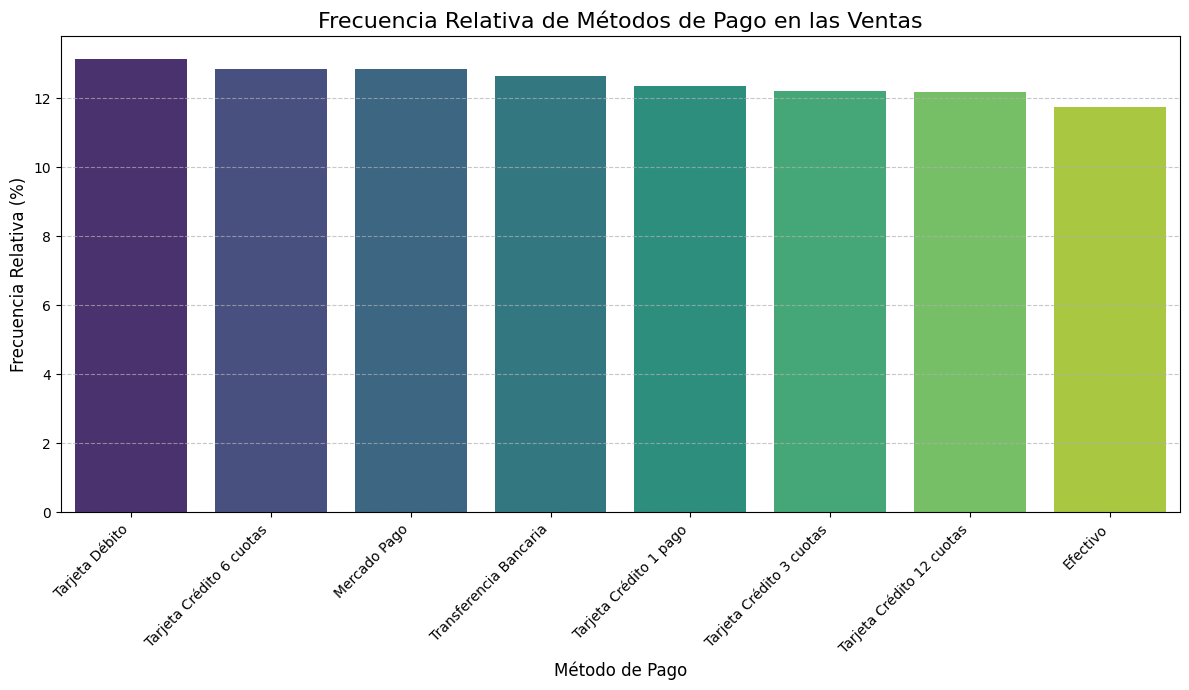


Paso 1
  
Pensamiento: Action: analytics_tool
Action Input: Graficar la frecuencia relativa de cada medio de pago en las ventas realizadas.
  
Herramienta: analytics_tool
  
Input: Graficar la frecuencia relativa de cada medio de pago en las ventas realizadas.
  
Resultado: Gráfico generado correctamente.generado mediante 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

resultado = ""

try:
    df_ventas = dfs['ventas']

    # Calcular la frecuencia relativa de cada método de pago
    frecuencia_relativa = df_ventas['metodo_pago'].value_counts(normalize=True) * 100

    # Crear el gráfico de barras
    plt.figure(figsize=(12, 7))
    sns.barplot(x=frecuencia_relativa.index, y=frecuencia_relativa.values, palette='viridis')

    # Añadir título y etiquetas
    plt.title('Frecuencia Relativa de Métodos de Pago en las Ventas', fontsize=16)
    plt.xlabel('Método de Pago', fontsize=12)
    plt.ylabel('Frecuencia Relativa (%)', fontsize=12)
    plt.xticks(rotation

In [ ]:
consultar_agente("Gráfico de la frecuencia relativa de cada medio de pago en las ventas realizadas", steps=True)

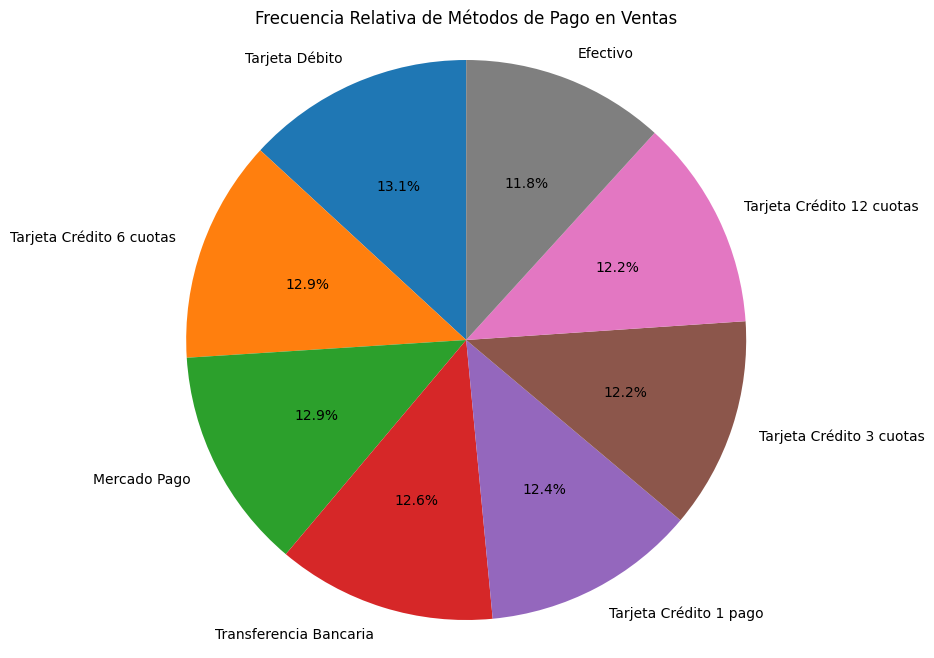


Paso 1
  
Pensamiento: Action: analytics_tool
Action Input: Graficar la frecuencia relativa de cada medio de pago en las ventas realizadas como un gráfico de pastel (piechart).
  
Herramienta: analytics_tool
  
Input: Graficar la frecuencia relativa de cada medio de pago en las ventas realizadas como un gráfico de pastel (piechart).
  
Resultado: El gráfico se generó correctamente.generado mediante 
import pandas as pd
import matplotlib.pyplot as plt

try:
    df_ventas = dfs['ventas']

    # Contar la frecuencia de cada método de pago
    frecuencia_metodos_pago = df_ventas['metodo_pago'].value_counts()

    # Calcular la frecuencia relativa (porcentaje)
    frecuencia_relativa = frecuencia_metodos_pago / frecuencia_metodos_pago.sum() * 100

    # Generar el gráfico de pastel
    plt.figure(figsize=(10, 8))
    plt.pie(frecuencia_relativa, labels=frecuencia_relativa.index, autopct='%1.1f%%', startangle=90)
    plt.title('Frecuencia Relativa de Métodos de Pago en Ventas')
    plt.axis

In [ ]:
consultar_agente("Damelo como piechart", steps=True)

Los gráficos generados son correctos, y entendió correctamente que le estaba pidiendo otro tipo de gráfico sobre la misma información de antes.

In [21]:
consultar_agente("Decime quienes son los usuarios que mas compraron, cuanto compraron y quien les vendió", steps=True)


Paso 1
  
Pensamiento: Action: graph_search
Action Input: usuarios que mas compraron, el monto total de sus compras y los vendedores involucrados.
  
Herramienta: graph_search
  
Input: usuarios que mas compraron, el monto total de sus compras y los vendedores involucrados.
  
Resultado: [{'Usuario': 'Ignacio Castillo', 'montoTotalCompras': 270033.3600000003, 'vendedoresInvolucrados': ['Laura Rodríguez', 'Carlos Rojas', 'Benjamín Suárez', 'Emilia Mendoza', 'Florencia Ríos', 'Jazmín Medina', 'Santiago Flores', 'Tomás Romero', 'Joaquín Castillo', 'Ignacio Molina']}, {'Usuario': 'Pablo Cruz', 'montoTotalCompras': 249139.4399999999, 'vendedoresInvolucrados': ['Carlos Flores', 'Renata García', 'Thiago Rodríguez', 'Benjamín Suárez', 'Bianca Suárez', 'Milagros Hernández', 'Santiago Flores', 'María Benítez', 'Martina Rojas', 'Santiago Vega']}, {'Usuario': 'Gonzalo Cabrera', 'montoTotalCompras': 242176.86999999985, 'vendedoresInvolucrados': ['Emanuel Navarro', 'Gonzalo Ríos', 'Adrián Reyes', '

In [22]:
historial_agente.pop(-1) # Borro ultima interacción del historial

('Decime quienes son los usuarios que mas compraron, cuanto compraron y quien les vendió',
 'Los 3 usuarios que más compraron son:\n*   **Ignacio Castillo**: Compró un total de $270033.36. Los vendedores involucrados fueron: Laura Rodríguez, Carlos Rojas, Benjamín Suárez, Emilia Mendoza, Florencia Ríos, Jazmín Medina, Santiago Flores, Tomás Romero, Joaquín Castillo, Ignacio Molina.\n*   **Pablo Cruz**: Compró un total de $249139.44. Los vendedores involucrados fueron: Carlos Flores, Renata García, Thiago Rodríguez, Benjamín Suárez, Bianca Suárez, Milagros Hernández, Santiago Flores, María Benítez, Martina Rojas, Santiago Vega.\n*   **Gonzalo Cabrera**: Compró un total de $242176.87. Los vendedores involucrados fueron: Emanuel Navarro, Gonzalo Ríos, Adrián Reyes, Martina Castillo, Facundo Fernández, Juan Díaz, Benjamín Álvarez, Laura Álvarez, Matías Vargas, Adrián Martínez, Antonella Medina, Santiago Aguilar.')

In [23]:
consultar_agente("Decime quienes son los usuarios que mas compraron, cuanto compraron y quien les vendió", steps=True)


Paso 1
  
Pensamiento: Question: Decime quienes son los usuarios que mas compraron, cuanto compraron y quien les vendió
Thought: El usuario quiere saber quiénes son los usuarios que más compraron, cuánto compraron y quién les vendió. Esto implica buscar relaciones entre usuarios, ventas y vendedores, y también sumar las cantidades de las compras. La herramienta `graph_search` es la más adecuada para consultar relaciones entre entidades y sus atributos.
Action: graph_search
Action Input: Usuarios que mas compraron, el monto total de sus compras y los vendedores que les vendieron.
  
Herramienta: graph_search
  
Input: Usuarios que mas compraron, el monto total de sus compras y los vendedores que les vendieron.
  
Resultado: [{'Usuario': 'Ignacio Castillo', 'MontoTotalCompras': 22502.780000000002, 'VendedoresQueAtendieron': ['Laura', 'Carlos', 'Benjamín', 'Emilia', 'Florencia', 'Jazmín', 'Santiago', 'Tomás', 'Joaquín', 'Ignacio']}, {'Usuario': 'María Gutiérrez', 'MontoTotalCompras': 219

Montos totales calculados inconsistentes.

Mas pruebas (Ahora sin mostrar los pasos intermedios *steps=False* para analizar únicamente resultados limpios)

In [ ]:
consultar_agente("Cual es el ratio ventas/devoluciones de cada sucursal?")

A continuación se presenta el ratio ventas/devoluciones para cada sucursal:

*   **Buenos Aires:** 4.43
*   **CABA:** 5.33
*   **Catamarca:** 5.88
*   **Chubut:** 5.86
*   **Corrientes:** 4.63
*   **Córdoba:** 3.68
*   **Entre Ríos:** 4.86
*   **Formosa:** 4.21
*   **Jujuy:** 5.25
*   **La Pampa:** 7.46
*   **La Rioja:** 5.81
*   **Mendoza:** 4.33
*   **Misiones:** 5.09
*   **Neuquén:** 4.15
*   **Río Negro:** 3.52
*   **Salta:** 5.98
*   **San Juan:** 4.59
*   **San Luis:** 4.75
*   **Santa Cruz:** 4.70
*   **Santa Fe:** 4.88
*   **Santiago del Estero:** 6.32
*   **Tierra del Fuego:** 6.27
*   **Tucumán:** 4.09


In [ ]:
consultar_agente("Soy Juan Flores, recomiendame un producto basandote en mis compras mas recientes")

Basado en tus compras recientes de electrodomésticos de cocina como la licuadora, el microondas, la waflera, la olla de cocción lenta y el frigobar, te recomiendo la **Profesional Parrilla Eléctrica 3000** de ChefMaster. Sería un excelente complemento para tu cocina y te permitiría ampliar tus opciones de preparación de alimentos.


<string>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



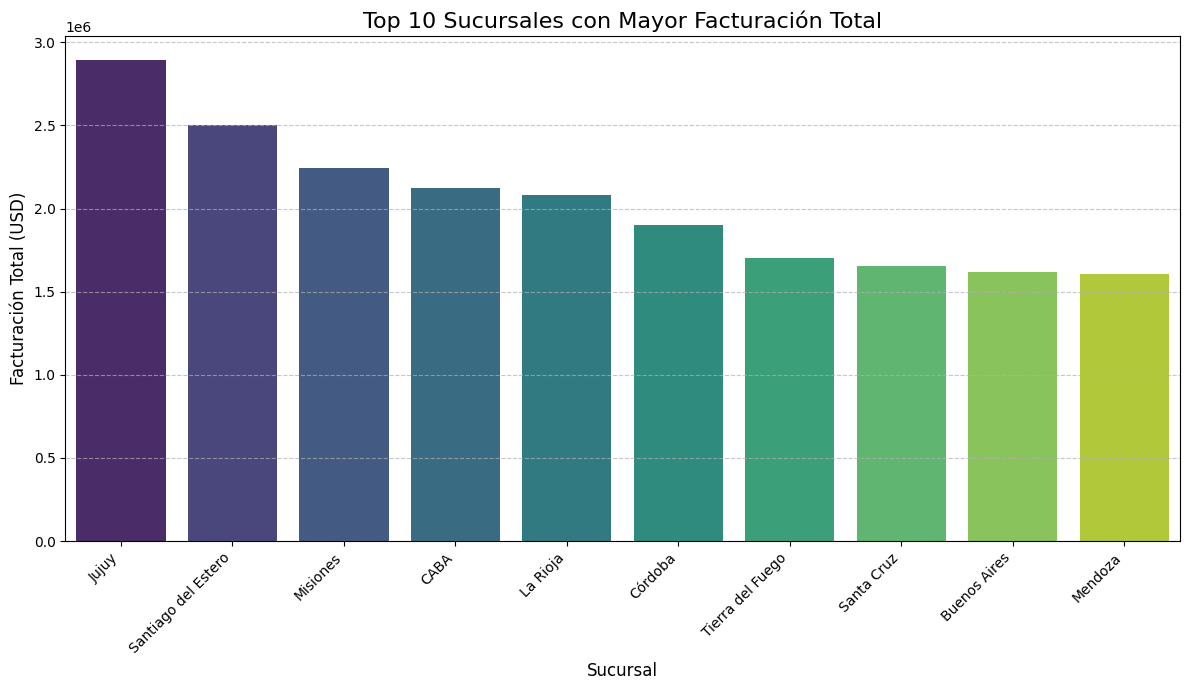

La sucursal que más facturó en total es Jujuy. Se ha generado un gráfico de barras comparando las ventas totales de las principales 10 sucursales.


In [ ]:
consultar_agente("Quiero saber cual es la sucursal que más facturó en total, tambien necesito un gráfico de barras comparando las ventas totales de las principales 10 sucursales para ver la diferencia")

In [ ]:
consultar_agente("Busca un usuario que haya abierto un ticket de máxima severidad. Dime su nombre, qué producto reclamó y busca si hay reseñas de otros usuarios reportando ese mismo problema")

Un usuario que abrió un ticket de máxima severidad es Juan Castillo, quien reclamó por el producto Ventilador de Torre 2024. Se han encontrado reseñas de otros usuarios que reportan problemas similares, como que el producto "se rompió a los pocos días" y es "muy complicado y ruidoso".


In [ ]:
consultar_agente("Que voltaje usa mi cafetera?")

La Deluxe Cafetera 2024 usa 12V. La Premium Cafetera también funciona con 12V.


In [ ]:
consultar_agente("Cuantos meses de garantía tiene mi secarropa P0259?")

Tu secarropa P0259 tiene 36 meses de garantía.


In [ ]:
consultar_agente("Tiene olor a quemado")

Si tu electrodoméstico tiene olor a quemado, las posibles causas pueden ser un motor sobrecargado, uso excesivo sin pausas, ingredientes pegados en el motor, un cortocircuito eléctrico o componentes internos dañados.

Para solucionar esto, te recomiendo seguir estos pasos:
1.  **APAGAR INMEDIATAMENTE** el electrodoméstico y desconectarlo de la corriente.
2.  Dejar que se enfríe completamente (aproximadamente 30-60 minutos).
3.  Limpiar cualquier residuo que pueda haber alrededor del eje del motor.
4.  Si el olor persiste después de limpiar y enfriar, **NO USAR** el electrodoméstico y llevarlo a un servicio técnico. Podría ser necesario reemplazar el motor.

Para una ayuda más específica, por favor, dime qué electrodoméstico es el que tiene el olor a quemado.


In [ ]:
consultar_agente("Quien es el vendedor con mayor cantidad de tickets abiertos de máxima severidad asignados? Listalos")

La vendedora con la mayor cantidad de tickets abiertos de máxima severidad asignados es Laura Álvarez. Los tickets son los siguientes:
*   TKT000758: Problema - No enciende, Severidad - Alta, Estado - Abierto
*   TKT001122: Problema - Defecto de fábrica, Severidad - Alta, Estado - Abierto
*   TKT001348: Problema - No enciende, Severidad - Alta, Estado - Abierto
*   TKT000026: Problema - Defecto de fábrica, Severidad - Alta, Estado - Abierto


In [ ]:
consultar_agente("Que usuario dejó mayor cantidad de reseñas negativas?")

El usuario que dejó la mayor cantidad de reseñas negativas es Bautista Ramírez, con un total de 8 reseñas.


In [ ]:
consultar_agente("Compara las reseñas y determina si son falsas")

No tengo la capacidad de comparar reseñas y determinar si son falsas. Mis herramientas están diseñadas para buscar información, pero no para realizar análisis cualitativos o emitir juicios sobre la veracidad del contenido de las reseñas.


In [ ]:
consultar_agente("Que juego ganó el premio GOTY en 2025?")

Lo siento, pero no puedo responder preguntas que no estén relacionadas con electrodomésticos.


El desempeño del agente es muy bueno, limitandosé a contestar preguntas relacionadas a su base de conocimiento y usando únicamente las herramientas proporcionadas. Es capaz de comprender el contexto usando el historial y de combinar herramientas para responder correctamente.